In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dill
import lzma
import numpy as np
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, train_test_split, HalvingGridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearnex.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
import joblib
from datetime import datetime

Preprocessing pipeline from previous section is used for data preprocessing.

In [2]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

with lzma.open('./saves/preprocessing_pipeline.xz', 'rb') as file:
    pipe = dill.load(file)

df = pipe.transform(df)

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1, stratify=y)

Data obtained during evaluation of different resampling methods from previous section is used as 0 iteration for hyperparameters tuning.

In [3]:
try:
    stats = joblib.load('./saves/models_training.pkl')
except:
    stats = pd.DataFrame(columns=['model', 'iteration', 'f1_train', 'f1_test', 'accuracy_test'])

    scores = joblib.load('./saves/resampling_selection.pkl')  # getting results for 0 iterations
    train_scores = scores['train_scores']
    train_scores = train_scores[train_scores['sampler'] == 'NoResampling']
    test_scores = scores['test_scores']
    test_scores = test_scores[test_scores['sampler'] == 'NoResampling']

    for model_name in ['Nearest Neighbor', 'Decision Tree', 'Random Forest', 'MLPC']:
        f1_train = train_scores.loc[train_scores['model'] == model_name, 'value'].mean()
        f1_test = test_scores.loc[(test_scores['model'] == model_name) & (test_scores['metric'] == 'f1'), 'value'].item()
        accuracy = test_scores.loc[(test_scores['model'] == model_name) & (test_scores['metric'] == 'accuracy'), 'value'].item()
        stats.loc[len(stats.index)] = {'model': model_name, 'iteration': 0, 'f1_train': f1_train, 'f1_test': f1_test, 'accuracy_test': accuracy}

The function below is used for searching for hyperparameters search in two modes: HalvingGridSearchCV and GridSearchCV

In [4]:
def gs_cv(model_name, iteration, model, params, search_type, n_jobs=10):
    if stats[(stats['model'] == model_name) & (stats['iteration'] == iteration)].shape[0] > 0:
        raise ValueError('Search with this same name already exists')  # in case the search iteration with same number was already recorded, kindly show an error

    start = datetime.now()
    cv = RepeatedStratifiedKFold(random_state=1)

    if search_type == 'grid':
        gs = GridSearchCV(model, cv=cv, param_grid=params, scoring='f1', n_jobs=n_jobs)
    else:
        gs = HalvingGridSearchCV(model, cv=cv, param_grid=params, scoring='f1', n_jobs=n_jobs, random_state=1, aggressive_elimination=True)
        
    gs.fit(X_train, y_train)    
    pred = gs.predict(X_test)

    f1_train = gs.best_score_
    f1_test = f1_score(y_test, pred)
    accuracy_test = accuracy_score(y_test, pred)
    
    # iteration's data is stored
    stats.loc[len(stats.index)] = [model_name, iteration, f1_train, f1_test, accuracy_test]
    joblib.dump(stats, './saves/models_training.pkl')
    joblib.dump(gs, './saves/models_training/' + model_name + '_' + str(iteration) + '.pkl')  # whole GridSearch is saved to store best_estimator_ and training scores
    
    print('\nTime:', (datetime.now() - start).seconds /60 /60)  # hours
    print('Best params:', gs.best_params_)

    print('Train set f1:', f1_train)
    print('Test set f1:', f1_test)
    
    print('Test set accuracy:', accuracy_test)

    return gs

Function below plots train and test scores for all iterations, selects best result and calculates confusion matrix and classification report for it.

In [5]:
def tuneplot(model_name):
    ax = sns.lineplot(data=stats[stats['model'] == model_name], x='iteration', y='f1_test', label='Test')
    sns.lineplot(data=stats[stats['model'] == model_name], x='iteration', y='f1_train', label='Train', color='g')

    max_test_score = stats.loc[stats['model'] == model_name, 'f1_test'].max()
    best_iteration = stats.loc[(stats['model'] == model_name) & (stats['f1_test'] == max_test_score), 'iteration'].iloc[0]
    plt.axvline(x=best_iteration, color='r', linestyle=':')  # marking best score
    
    ax.set_title(model_name + ' f1 score over hyperparameters tuning iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('F1 score')
    
    ax.set_xticks(range(0, stats[stats['model'] == model_name].shape[0]))  # to remove decimal ticks
    ax.legend(loc='upper right')
    plt.show()

    best_model = joblib.load('./saves/models_training/' + model_name + '_' + str(best_iteration) + '.pkl').best_estimator_
    pred = best_model.predict(X_test)
    
    print('Confusion matrix:')
    print(confusion_matrix(y_test, pred), '\n')
    print('Classification report:')
    print(classification_report(y_test, pred, target_names=['Not fraud', 'Fraud']))

This is baseline for further tuning.</br>
These are the scores obtained for models with default settings.

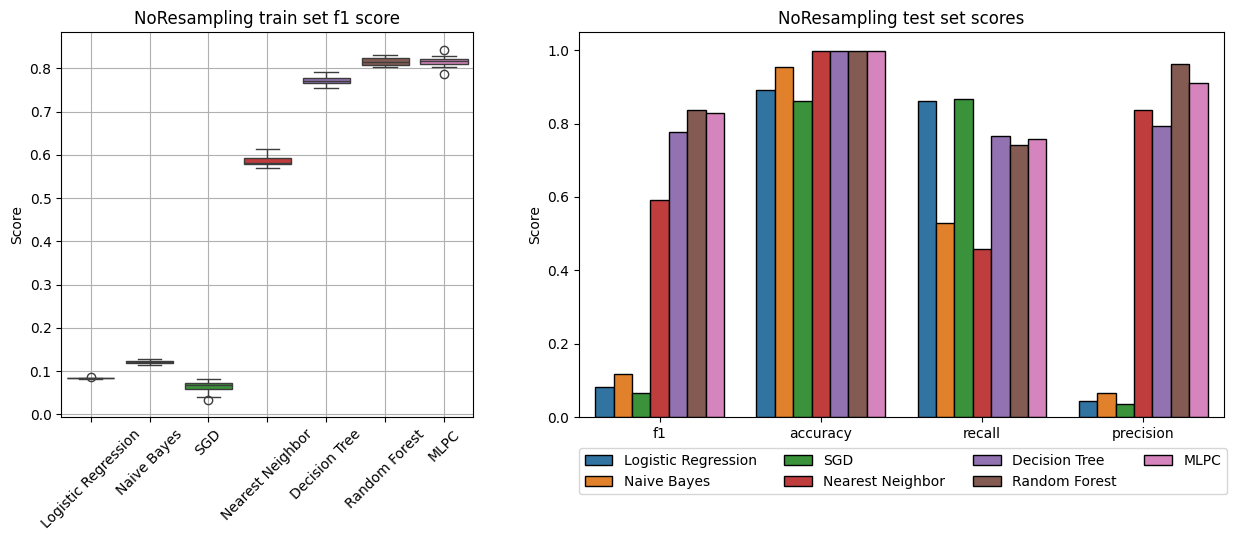

### Nearest Neighbor

Baseline scores for Nearest Neighbor:

In [12]:
stats[stats['model'] == 'Nearest Neighbor']

,model,iteration,f1_train,f1_test,accuracy_test
0,Nearest Neighbor,0,0.585978,0.59152,0.996344


Looking for promising hyperparameters with halving grid search.

In [10]:
params = [{
            'n_neighbors': range(2, 7),
            'metric': ['euclidean', 'manhattan', 'minkowski'],
            'weights': ['uniform', 'distance']
          }]

gs = gs_cv('Nearest Neighbor', 1, KNeighborsClassifier(), params, n_jobs=1, search_type = 'halving')

Time: 2.6816666666666666
Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Train set f1: 0.6526243581826817
Test set f1: 0.6634920634920636
Test set accuracy: 0.9967301006573731


Using grid search to evaluate neighboring hyperparameter values that could be missed during halving grid search.

In [13]:
params = [{
            'n_neighbors': range(2, 5),
            'metric': ['euclidean', 'manhattan', 'minkowski'],
            'weights': ['uniform', 'distance']
          }]

gs = gs_cv('Nearest Neighbor', 2, KNeighborsClassifier(), params, n_jobs=1, search_type = 'grid')

Time: 7.279444444444445
Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Train set f1: 0.6618756596723895
Test set f1: 0.6863979848866498
Test set accuracy: 0.996927528542211


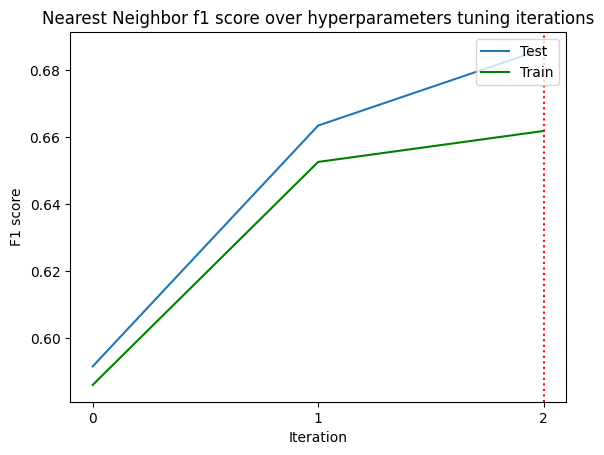

Confusion matrix:
[[322081    211]
 [   787   1090]] 

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00    322292
       Fraud       0.84      0.58      0.69      1877

    accuracy                           1.00    324169
   macro avg       0.92      0.79      0.84    324169
weighted avg       1.00      1.00      1.00    324169



In [6]:
tuneplot('Nearest Neighbor')

### Decision Tree

Baseline scores for Decision Tree:

In [146]:
stats[stats['model'] == 'Decision Tree']

,model,iteration,f1_train,f1_test,accuracy_test
1,Decision Tree,0,0.772156,0.758014,0.997113


Decision tree training is fast, so grid search is used here.

In [19]:
params = [{
            'criterion': ['gini', 'entropy', 'log_loss'],
            'max_features': ['sqrt', 'log2', None] 
          }]

gs = gs_cv('Decision Tree', 1, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.12111111111111111
Best params: {'criterion': 'entropy', 'max_features': None}
Train set f1: 0.7831393761953044
Test set f1: 0.794684024952536
Test set accuracy: 0.9976647982996524


What is maximum tree depth for unrestricted tree?

In [149]:
gs.best_estimator_.get_depth()

76

Knowing unrestricted tree depth, we can check if restricting it can boost generalization.

In [5]:
params = [{
            'criterion': ['entropy',],
            'min_samples_split': range(2, 6),
            'min_samples_leaf': range(1, 6),
            'max_depth': range(65, 76, 5)
          }]

gs = gs_cv('Decision Tree', 2, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 1.5552777777777778
Best params: {'criterion': 'entropy', 'max_depth': 75, 'min_samples_leaf': 1, 'min_samples_split': 2}
Train set f1: 0.783015525033305
Test set f1: 0.7967435549525101
Test set accuracy: 0.9976894767852571


What are test set scores for smaller depth?

In [6]:
params = [{
            'criterion': ['entropy',],
            'max_depth': [70,]
          }]

gs = gs_cv('Decision Tree', 3, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.030833333333333334
Best params: {'criterion': 'entropy', 'max_depth': 70}
Train set f1: 0.7829763731557989
Test set f1: 0.7969556944821962
Test set accuracy: 0.9976956464066583


In [7]:
params = [{
            'criterion': ['entropy',],
            'max_depth': [65,]
          }]

gs = gs_cv('Decision Tree', 4, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.03222222222222222
Best params: {'criterion': 'entropy', 'max_depth': 65}
Train set f1: 0.7829700439239603
Test set f1: 0.7937195452084461
Test set accuracy: 0.9976493742461494


f1 score was reduced both for train and test sets with depth 65. So, probably a better option lays between 65 and 70.

In [8]:
params = [{
            'criterion': ['entropy',],
            'max_depth': [68,]
          }]

gs = gs_cv('Decision Tree', 5, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.03194444444444445
Best params: {'criterion': 'entropy', 'max_depth': 68}
Train set f1: 0.7828687902761507
Test set f1: 0.7962059620596206
Test set accuracy: 0.9976802223531553


In [10]:
params = [{
            'criterion': ['entropy',],
            'max_depth': [69,]
          }]

gs = gs_cv('Decision Tree', 6, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.0325
Best params: {'criterion': 'entropy', 'max_depth': 69}
Train set f1: 0.782930296599727
Test set f1: 0.7960954446854664
Test set accuracy: 0.9976802223531553


f1 score on test dataset for depth 69 is lower that for 68 and 70, showing that there is no correlation between depth and f1 score on selected range. It may be beneficial to check other depth values.

In [11]:
params = [{
            'criterion': ['entropy',],
            'max_depth': [72,]
          }]

gs = gs_cv('Decision Tree', 7, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.0325
Best params: {'criterion': 'entropy', 'max_depth': 72}
Train set f1: 0.7829089022441604
Test set f1: 0.7972789115646258
Test set accuracy: 0.9977018160280594


In [13]:
params = [{
            'criterion': ['entropy',],
            'max_depth': [73,]
          }]

gs = gs_cv('Decision Tree', 8, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.03194444444444445
Best params: {'criterion': 'entropy', 'max_depth': 73}
Train set f1: 0.7827440974690991
Test set f1: 0.79491341991342
Test set accuracy: 0.9976617134889517


In [14]:
params = [{
            'criterion': ['entropy',],
            'max_depth': [71,]
          }]

gs = gs_cv('Decision Tree', 9, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.03166666666666666
Best params: {'criterion': 'entropy', 'max_depth': 71}
Train set f1: 0.7828882581619386
Test set f1: 0.7966286025013595
Test set accuracy: 0.9976925615959576


Max depth 72 showed the best result for now, so it will be taken for future tests.<br>
Next hyperparameter for tuning will be min_samples_split. By default it is 2.

In [15]:
params = [{
            'criterion': ['entropy',],
            'max_depth': [72,],
            'min_samples_split': [5]
          }]

gs = gs_cv('Decision Tree', 10, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.03166666666666666
Best params: {'criterion': 'entropy', 'max_depth': 72, 'min_samples_split': 5}
Train set f1: 0.7766969121860263
Test set f1: 0.7891920813269128
Test set accuracy: 0.997569169167934


In [16]:
params = [{
            'criterion': ['entropy'],
            'max_depth': [72],
            'min_samples_split': [3]
          }]

gs = gs_cv('Decision Tree', 11, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.03138888888888889
Best params: {'criterion': 'entropy', 'max_depth': 72, 'min_samples_split': 3}
Train set f1: 0.7805525662540156
Test set f1: 0.7925646551724138
Test set accuracy: 0.9976246957605447


Changing min_samples_split didn't show improvement over default value, so default value will be used.

In [18]:
params = [{
            'criterion': ['entropy'],
            'max_depth': [72],
            'min_samples_leaf': [5]
          }]

gs = gs_cv('Decision Tree', 12, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.03138888888888889
Best params: {'criterion': 'entropy', 'max_depth': 72, 'min_samples_leaf': 5}
Train set f1: 0.7354749502848754
Test set f1: 0.7422082628654264
Test set accuracy: 0.996708506982469


In [19]:
params = [{
            'criterion': ['entropy'],
            'max_depth': [72],
            'min_samples_leaf': [2]
          }]

gs = gs_cv('Decision Tree', 13, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.030833333333333334
Best params: {'criterion': 'entropy', 'max_depth': 72, 'min_samples_leaf': 2}
Train set f1: 0.7736773202847137
Test set f1: 0.7816938453445554
Test set accuracy: 0.9974396071185092


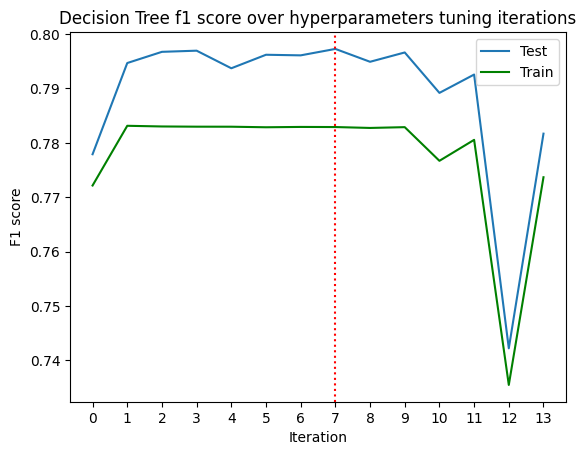

Confusion matrix:
[[321961    331]
 [   414   1463]] 

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00    322292
       Fraud       0.82      0.78      0.80      1877

    accuracy                           1.00    324169
   macro avg       0.91      0.89      0.90    324169
weighted avg       1.00      1.00      1.00    324169



In [7]:
tuneplot('Decision Tree')

Tuning min_samples_split and min_samples_leaf did not result in performance boost, leaving 7th iteration the winner among decision trees.

### Random Forest

Baseline scores for Random Forest:

In [6]:
stats[stats['model'] == 'Random Forest']

,model,iteration,f1_train,f1_test,accuracy_test
2,Random Forest,0,0.816389,0.836943,0.998328


In [20]:
params = [{
            'n_estimators': np.linspace(100, 1000, 5).astype(int),  
            'min_samples_split': np.linspace(2, 40, 5).astype(int),
            'min_samples_leaf': np.linspace(1, 20, 5).astype(int)
          }]

gs = gs_cv('Random Forest', 1, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='halving')

Time: 10.232777777777779
Best params: {'min_samples_leaf': 10, 'min_samples_split': 30, 'n_estimators': 325}
Train set f1: 0.7995930962020934
Test set f1: 0.8119266055045872
Test set accuracy: 0.9977234097029636


Halving grid search missed stronger model with default parameters, so it's better to use usual grid search.<br>
First let's try to change criterion.

In [21]:
params = [{
            'n_estimators': [100],
            'criterion': ['entropy']
          }]

gs = gs_cv('Random Forest', 2, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.3313888888888889
Best params: {'criterion': 'entropy', 'n_estimators': 100}
Train set f1: 0.8290268372093615
Test set f1: 0.8444045481747456
Test set accuracy: 0.9983958984356925


Criterion = entropy showed improvement, so it can be kept.

In [22]:
params = [{
            'n_estimators': np.linspace(200, 1000, 5).astype(int),
            'criterion': ['entropy']
          }]

gs = gs_cv('Random Forest', 3, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 8.523611111111112
Best params: {'criterion': 'entropy', 'n_estimators': 800}
Train set f1: 0.8315986027897821
Test set f1: 0.8452807646356034
Test set accuracy: 0.9984020680570936


Best model had n_estimators = 800, so we can test range 600-1000, excluding 600, 800 and 1000 as these values have already been tested.

In [23]:
params = [{
            'n_estimators': np.linspace(650, 950, 5).astype(int),
            'criterion': ['entropy']
          }]

gs = gs_cv('Random Forest', 4, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 11.2
Best params: {'criterion': 'entropy', 'n_estimators': 725}
Train set f1: 0.8317881962887445
Test set f1: 0.844338213325366
Test set accuracy: 0.9983928136249919


Increased amount of estimators increases mostly training time instead of f1 score. Target score differs not much from score with default 100 estimators, so default value will be used for tuning other parameters. Tuning number of estimators will be done later.<br>
Now I will focus on single tree parameters, forcing it to generalise.

In [25]:
params = [{
            'n_estimators': [100],
            'criterion': ['entropy'],
            'max_depth': [25, 50, None],
            'min_samples_split': [2, 3],
            'min_samples_leaf': [1, 2]
          }]

gs = gs_cv('Random Forest', 5, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 3.3469444444444445
Best params: {'criterion': 'entropy', 'max_depth': 50, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Train set f1: 0.8369974710449157
Test set f1: 0.8493797991730656
Test set accuracy: 0.9984267465426984


max_depth values were taken by guess, but one of them showed score improvement. Let's find max_depth with best score, while also checking better values for min_samples_split and min_samples_leaf.

In [26]:
params = [{
            'n_estimators': [100],
            'criterion': ['entropy'],
            'max_depth': [50, 60],
            'min_samples_split': [2],
            'min_samples_leaf': [3]
          }]

gs = gs_cv('Random Forest', 6, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.6158333333333333
Best params: {'criterion': 'entropy', 'max_depth': 50, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Train set f1: 0.8400372044441866
Test set f1: 0.8525827045850262
Test set accuracy: 0.9984329161640996


In [27]:
params = [{
            'n_estimators': [100],
            'criterion': ['entropy'],
            'max_depth': [45, 50, 55],
            'min_samples_split': [2],
            'min_samples_leaf': [4]
          }]

gs = gs_cv('Random Forest', 7, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.8608333333333333
Best params: {'criterion': 'entropy', 'max_depth': 55, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Train set f1: 0.839809457247117
Test set f1: 0.8547788873038517
Test set accuracy: 0.998429831353399


In [28]:
params = [{
            'n_estimators': [100],
            'criterion': ['entropy'],
            'max_depth': [55, 60],
            'min_samples_split': [2],
            'min_samples_leaf': [5, 6]
          }]

gs = gs_cv('Random Forest', 8, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 1.1241666666666668
Best params: {'criterion': 'entropy', 'max_depth': 55, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Train set f1: 0.8370913401836486
Test set f1: 0.8543362335110861
Test set accuracy: 0.9983989832463931


Iteration 7 showed better results, so min_samples_leaf = 4 will be used. Can changing max_features improve score? 

In [29]:
params = [{
            'n_estimators': [100],
            'criterion': ['entropy'],
            'max_depth': [55],
            'min_samples_split': [2],
            'min_samples_leaf': [4],
            'max_features': ['sqrt', 'log2']
          }]

gs = gs_cv('Random Forest', 9, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 0.5330555555555556
Best params: {'criterion': 'entropy', 'max_depth': 55, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Train set f1: 0.8400250907433986
Test set f1: 0.8548571428571429
Test set accuracy: 0.9984329161640996


Nope...<br>
As other hyperparameters were selected, it's time to return to n_estimators, the most time consuming one.

In [30]:
params = [{
            'n_estimators': np.linspace(50, 400, 5).astype(int),
            'criterion': ['entropy'],
            'max_depth': [55],
            'min_samples_split': [2],
            'min_samples_leaf': [4],
            'max_features': ['sqrt']
          }]

gs = gs_cv('Random Forest', 10, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 3.291944444444445
Best params: {'criterion': 'entropy', 'max_depth': 55, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 312}
Train set f1: 0.8419083236571927
Test set f1: 0.8566533409480297
Test set accuracy: 0.9984514250283031


In [31]:
params = [{
            'n_estimators': np.linspace(250, 350, 5).astype(int),
            'criterion': ['entropy'],
            'max_depth': [55],
            'min_samples_split': [2],
            'min_samples_leaf': [4],
            'max_features': ['sqrt']
          }]

gs = gs_cv('Random Forest', 11, RandomForestClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Time: 4.250555555555556
Best params: {'criterion': 'entropy', 'max_depth': 55, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Train set f1: 0.842002471505486
Test set f1: 0.8572244431753284
Test set accuracy: 0.9984575946497043


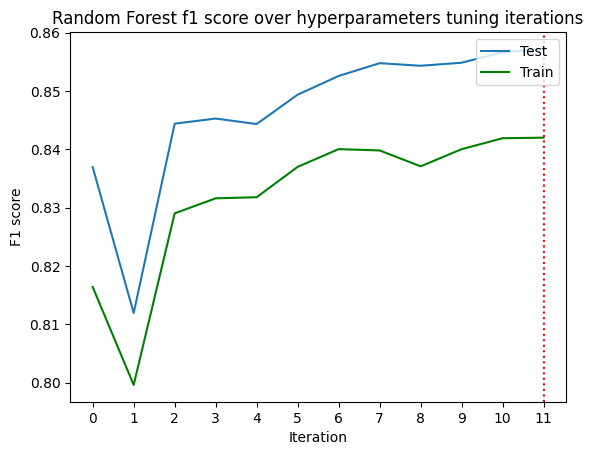

Confusion matrix:
[[322170    122]
 [   378   1499]] 

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00    322292
       Fraud       0.92      0.80      0.86      1877

    accuracy                           1.00    324169
   macro avg       0.96      0.90      0.93    324169
weighted avg       1.00      1.00      1.00    324169



In [8]:
tuneplot('Random Forest')

### MLPC

Baseline scores for MLPC:

In [9]:
stats[stats['model'] == 'MLPC']

,model,iteration,f1_train,f1_test,accuracy_test
3,MLPC,0,0.816152,0.827426,0.998168


At first I will test different hidden layer sizes.

In [32]:
params = [{
            'hidden_layer_sizes': [(60), (50), (40), (30), (20), (10)]
          }]

gs = gs_cv('MLPC', 1, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='halving')

Time: 0.40472222222222226
Best params: {'hidden_layer_sizes': 50}
Train set f1: 0.8131700085235112
Test set f1: 0.8256395177888857
Test set accuracy: 0.9981707072545494


As 50 was selected as best layer size, it can be assumed that range 40-60 contains the best size. Time to check different activation functions and solvers.

In [8]:
params = [{
            'hidden_layer_sizes': [(60), (50), (40)],
            'activation': ['logistic', 'tanh', 'relu'],
            'solver': ['lbfgs', 'sgd', 'adam']
          }]

gs = gs_cv('MLPC', 2, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='halving')

Time: 3.7611111111111111
Best params: {'activation': 'logistic', 'hidden_layer_sizes': 40, 'solver': 'adam'}
Train set f1: 0.8138236709749533
Test set f1: 0.8228472020875616
Test set accuracy: 0.9981151806619387


Solver and activation function selection can be crucial for the result, so let's better check it with grid search.

In [34]:
params = [{
            'hidden_layer_sizes': [(50), (40), (30)],
            'activation': ['logistic', 'tanh', 'relu'],
            'solver': ['lbfgs', 'sgd', 'adam']
          }]

gs = gs_cv('MLPC', 3, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 4.144444444444444
Best params: {'activation': 'relu', 'hidden_layer_sizes': 30, 'solver': 'lbfgs'}
Train set f1: 0.8209565165174021
Test set f1: 0.8350129570976101
Test set accuracy: 0.9982324034685611


Indeed, grid search shows different results. What's more important, it showed that a model with smaller hidden layer size can have better score. It's important for training time.

In [35]:
params = [{
            'hidden_layer_sizes': [(35), (25)],
            'activation': ['relu'],
            'solver': ['lbfgs']
          }]

gs = gs_cv('MLPC', 4, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 1.0533333333333335
Best params: {'activation': 'relu', 'hidden_layer_sizes': 25, 'solver': 'lbfgs'}
Train set f1: 0.8217393567944471
Test set f1: 0.8320787492762015
Test set accuracy: 0.9982108097936571


Iteration 4 showed better scores, so params from it will be used.<br>
Time to check how deep our neural network should be.

In [36]:
params = [{
            'hidden_layer_sizes': [(30,) * 5],
            'activation': ['relu'],
            'solver': ['lbfgs']
          }]

gs = gs_cv('MLPC', 5, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 6.53
Best params: {'activation': 'relu', 'hidden_layer_sizes': (30, 30, 30, 30, 30), 'solver': 'lbfgs'}
Train set f1: 0.7825973209341585
Test set f1: 0.8086522462562397
Test set accuracy: 0.9978714806165919


Making the network more deep reduced it's score. Maybe the solver was chosen poorly.

In [37]:
params = [{
            'hidden_layer_sizes': [(30,) * 5],
            'activation': ['relu'],
            'solver': ['adam']
          }]

gs = gs_cv('MLPC', 6, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.29583333333333334
Best params: {'activation': 'relu', 'hidden_layer_sizes': (30, 30, 30, 30, 30), 'solver': 'adam'}
Train set f1: 0.8244914298506184
Test set f1: 0.8357779695139488
Test set accuracy: 0.9982385730899623


Yes, changing solver solved the issue. I can continue increasing hidden layers number.

In [38]:
params = [{
            'hidden_layer_sizes': [(30,) * 10],
            'activation': ['relu'],
            'solver': ['adam']
          }]

gs = gs_cv('MLPC', 7, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 0.7791666666666667
Best params: {'activation': 'relu', 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30), 'solver': 'adam'}
Train set f1: 0.8244632065526878
Test set f1: 0.8397202797202797
Test set accuracy: 0.9982324034685611


In [39]:
params = [{
            'hidden_layer_sizes': [(30,) * 15],
            'activation': ['relu'],
            'solver': ['adam']
          }]

gs = gs_cv('MLPC', 8, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 1.3416666666666666
Best params: {'activation': 'relu', 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30), 'solver': 'adam'}
Train set f1: 0.8245091336471359
Test set f1: 0.8437682855471036
Test set accuracy: 0.9983527110858842


Additional layers don't increase the score much, so I will tune something else.<br>
How changing strength of regularisation will affect the model?

In [40]:
params = [{
            'hidden_layer_sizes': [(30,) * 15],
            'activation': ['relu'],
            'solver': ['adam'],
            'alpha': [0.00001]
          }]

gs = gs_cv('MLPC', 9, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 1.168888888888889
Best params: {'activation': 'relu', 'alpha': 1e-05, 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30), 'solver': 'adam'}
Train set f1: 0.8257685084042541
Test set f1: 0.8489082969432314
Test set accuracy: 0.9983989832463931


In [41]:
params = [{
            'hidden_layer_sizes': [(30,) * 15],
            'activation': ['relu'],
            'solver': ['adam'],
            'alpha': [0.00002, 0.000005]
          }]

gs = gs_cv('MLPC', 10, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 1.9133333333333333
Best params: {'activation': 'relu', 'alpha': 2e-05, 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30), 'solver': 'adam'}
Train set f1: 0.8257641045086197
Test set f1: 0.8331332533013205
Test set accuracy: 0.9982848452504712


alpha 0.00001 seems to be the best value. Let's check learning rate value.

In [42]:
params = [{
            'hidden_layer_sizes': [(30,) * 15],
            'activation': ['relu'],
            'solver': ['adam'],
            'alpha': [0.00001],
            'learning_rate_init': [0.0013, 0.0007]
          }]

gs = gs_cv('MLPC', 11, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 2.076111111111111
Best params: {'activation': 'relu', 'alpha': 1e-05, 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30), 'learning_rate_init': 0.0013, 'solver': 'adam'}
Train set f1: 0.8244751127142375
Test set f1: 0.8486748361356512
Test set accuracy: 0.998361965517986


In [43]:
params = [{
            'hidden_layer_sizes': [(30,) * 15],
            'activation': ['relu'],
            'solver': ['adam'],
            'alpha': [0.00001],
            'learning_rate_init': [0.0014, 0.0012]
          }]

gs = gs_cv('MLPC', 12, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 2.0683333333333334
Best params: {'activation': 'relu', 'alpha': 1e-05, 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30), 'learning_rate_init': 0.0014, 'solver': 'adam'}
Train set f1: 0.8243477264437625
Test set f1: 0.8355355636772561
Test set accuracy: 0.9981953857401541


Default learning rate value showed the best score, so let's keep it. Can learning rate type change something?

In [44]:
params = [{
            'hidden_layer_sizes': [(30,) * 15],
            'activation': ['relu'],
            'solver': ['adam'],
            'alpha': [0.00001],
            'learning_rate': ['invscaling', 'adaptive']
          }]

gs = gs_cv('MLPC', 13, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Time: 1.9644444444444444
Best params: {'activation': 'relu', 'alpha': 1e-05, 'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30), 'learning_rate': 'invscaling', 'solver': 'adam'}
Train set f1: 0.8249896039263921
Test set f1: 0.8207792207792208
Test set accuracy: 0.9980843325549328


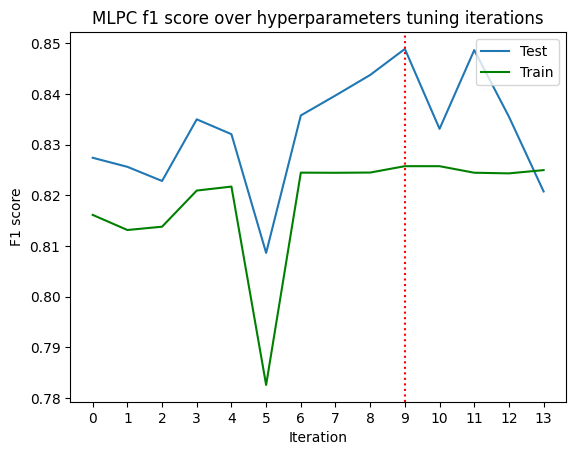

Confusion matrix:
[[322192    100]
 [   419   1458]] 

Classification report:
              precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00    322292
       Fraud       0.94      0.78      0.85      1877

    accuracy                           1.00    324169
   macro avg       0.97      0.89      0.92    324169
weighted avg       1.00      1.00      1.00    324169



In [9]:
tuneplot('MLPC')

### Final pipeline

Final pipeline will be preprocessing pipeline with added best classifier model.

In [6]:
print('Best model:',
      stats.loc[stats['f1_test'] == stats['f1_test'].max(), ['model', 'iteration']].to_string(index=False, header=False))

Best model: Random Forest 11


In [4]:
best_model = joblib.load('./saves/models_training/Random Forest_11.pkl').best_estimator_
pipe = make_pipeline(pipe, best_model)
    
#pipe

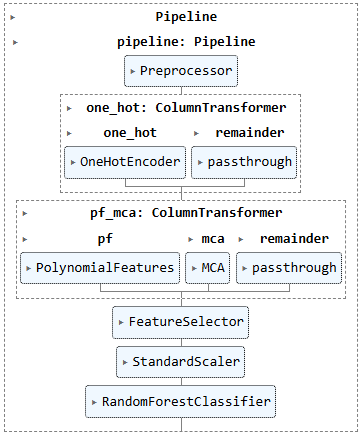

On the picture above you can see the resulting pipeline.<br>
Time to check if it works.

In [5]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

pred = pipe.predict(df)

print('Pipeline prediction f1:', f1_score(y, pred))
print('Pipeline prediction accuracy:', accuracy_score(y, pred))

stats[(stats['model'] == 'Random Forest') & (stats['iteration'] == 11)]

Pipeline prediction f1: 0.9507300486699112
Pipeline prediction accuracy: 0.9994300807835426


,model,iteration,f1_train,f1_test,accuracy_test
29,Random Forest,11,0.842002,0.857224,0.998458


Final pipeline has much better result on mix of training and test data, because it overits on training data, so the result seems ok and the pipeline can be saved.

In [6]:
with lzma.open('./saves/prediction_pipeline.xz', 'wb') as file:
    dill.dump(pipe, file)

### Grand test

Final test is performed on data from another file, not used before, providing 100% new data for the model.

In [13]:
with lzma.open('./saves/prediction_pipeline.xz', 'rb') as file:
    pipe_test = dill.load(file)

pipe_test_df = pd.read_csv('fraudTest.csv', index_col=0, parse_dates=['trans_date_trans_time'])
pipe_test_y = pipe_test_df['is_fraud']
pipe_test_df.drop(columns='is_fraud', inplace=True)

pipe_test_pred = pipe_test.predict(pipe_test_df)

print('Confusion matrix:\n', confusion_matrix(pipe_test_y, pipe_test_pred), '\n')
print('Classification report:\n', classification_report(pipe_test_y, pipe_test_pred, target_names=['Not fraud', 'Fraud'], digits=2))

Confusion matrix:
 [[553325    249]
 [   545   1600]] 

Classification report:
               precision    recall  f1-score   support

   Not fraud       1.00      1.00      1.00    553574
       Fraud       0.87      0.75      0.80      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.87      0.90    555719
weighted avg       1.00      1.00      1.00    555719



As expected, f1 score experienced slight drop, but not a huge one. Accuracy remains high.